In [6]:
import os
from pathlib import Path

# Ensure working directory is the project root, not the notebooks/ folder
if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working directory:", Path.cwd())

Working directory: c:\Users\micha\Downloads\CS158\Shot-Value-Machine-Learning


In [7]:
# import data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("data/processed/shot_logs_cleaned.csv")
print(df.shape)
df.head()

(127757, 19)


,player_name,matchup,location,period,game_clock_sec,shot_clock,shot_clock_missing,dribbles,touch_time,shot_dist,close_def_dist,pts_type,made,shot_clock_pct,game_clock_pct,catch_and_shoot,dribble_pull_up,def_dist_x_shot_dist,shot_dist_squared
0,brian roberts,"MAR 04, 2015 - CHA @ BKN",A,1,69,10.8,0,2,1.9,7.7,1.3,2,1,0.450000,0.095833,0,0,10.01,59.29
1,brian roberts,"MAR 04, 2015 - CHA @ BKN",A,1,14,3.4,0,0,0.8,28.2,6.1,3,0,0.141667,0.019444,1,0,172.02,795.24
2,brian roberts,"MAR 04, 2015 - CHA @ BKN",A,1,0,0.0,1,3,2.7,10.1,0.9,2,0,0.000000,0.000000,0,1,9.09,102.01
3,brian roberts,"MAR 04, 2015 - CHA @ BKN",A,2,707,10.3,0,2,1.9,17.2,3.4,2,0,0.429167,0.490972,0,0,58.48,295.84
4,brian roberts,"MAR 04, 2015 - CHA @ BKN",A,2,634,10.9,0,2,2.7,3.7,1.1,2,0,0.454167,0.440278,0,0,4.07,13.69


In [8]:
# summary statistics
df.describe()

,period,game_clock_sec,shot_clock,shot_clock_missing,dribbles,touch_time,shot_dist,close_def_dist,pts_type,made,shot_clock_pct,game_clock_pct,catch_and_shoot,dribble_pull_up,def_dist_x_shot_dist,shot_dist_squared
count,127757.000000,127757.000000,127757.000000,127757.000000,127757.00000,127757.000000,127757.000000,127757.000000,127757.000000,127757.000000,127757.000000,127757.000000,127757.000000,127757.000000,127757.000000,127757.000000
mean,2.469595,351.409011,11.909047,0.043473,2.02828,2.778727,13.576808,4.124012,2.264964,0.452468,0.496210,0.261106,0.460781,0.245990,68.800911,263.322114
std,1.139929,207.602250,6.175975,0.203920,3.48057,2.987196,8.887801,2.756188,0.441316,0.497738,0.257332,0.229415,0.498461,0.430675,72.177981,254.583617
min,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,172.000000,7.500000,0.000000,0.00000,0.900000,4.700000,2.300000,2.000000,0.000000,0.312500,0.095833,0.000000,0.000000,10.660000,22.090000
50%,2.000000,352.000000,12.000000,0.000000,1.00000,1.600000,13.700000,3.700000,2.000000,0.000000,0.500000,0.199537,0.000000,0.000000,45.530000,187.690000
75%,3.000000,531.000000,16.400000,0.000000,2.00000,3.700000,22.500000,5.300000,3.000000,1.000000,0.683333,0.338889,1.000000,0.000000,109.560000,506.250000
max,7.000000,720.000000,24.000000,1.000000,32.00000,24.900000,47.200000,53.200000,3.000000,1.000000,1.000000,0.995833,1.000000,1.000000,1061.400000,2227.840000


Overall FG%: 0.452


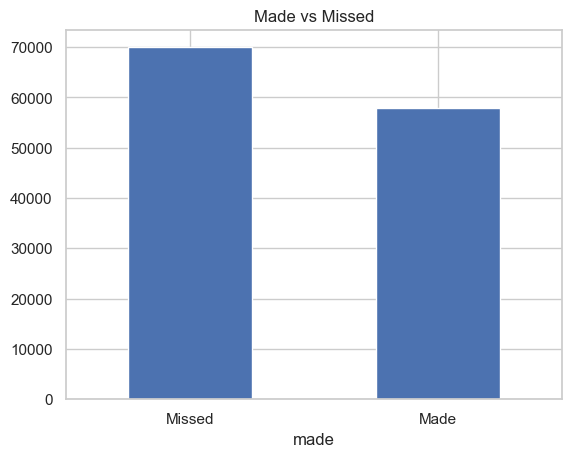

In [9]:
# target distribution: shot make rate
make_rate = df["made"].mean()
print(f"Overall FG%: {make_rate:.3f}")
df["made"].value_counts().plot(kind="bar", title="Made vs Missed")
plt.xticks([0, 1], ["Missed", "Made"], rotation=0)
plt.show()

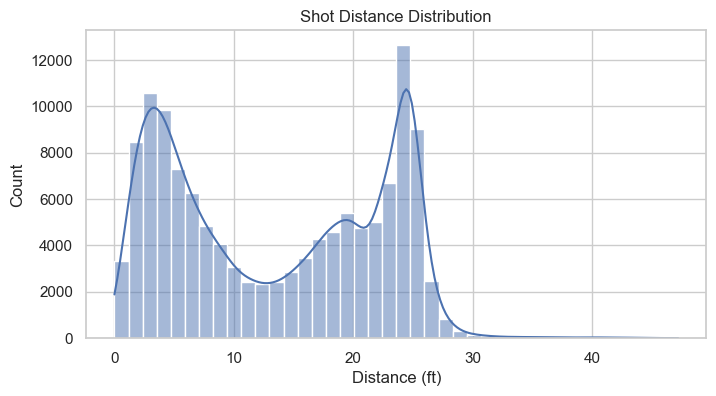

In [10]:
# shot distance distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["shot_dist"], bins=40, kde=True)
plt.title("Shot Distance Distribution")
plt.xlabel("Distance (ft)")
plt.show()

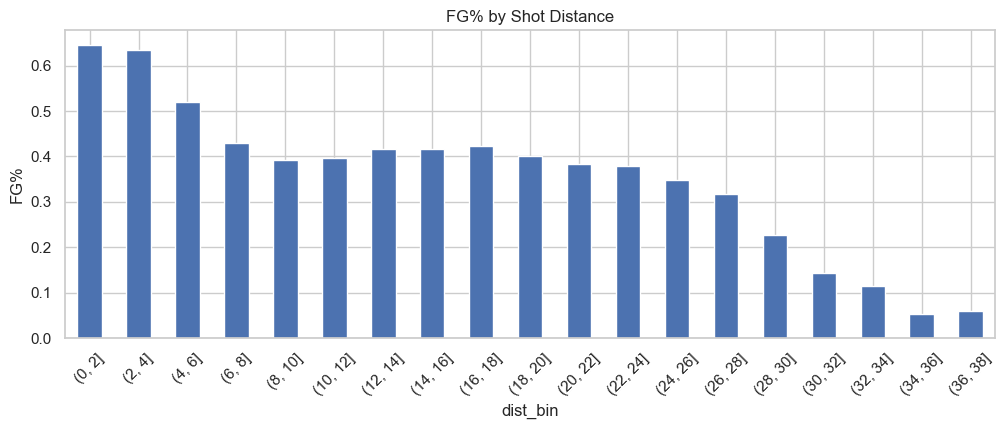

In [11]:
# make rate by shot distance (binned)
df["dist_bin"] = pd.cut(df["shot_dist"], bins=range(0, 40, 2))
make_by_dist = df.groupby("dist_bin")["made"].mean()
make_by_dist.plot(kind="bar", figsize=(12, 4), title="FG% by Shot Distance")
plt.ylabel("FG%")
plt.xticks(rotation=45)
plt.show()

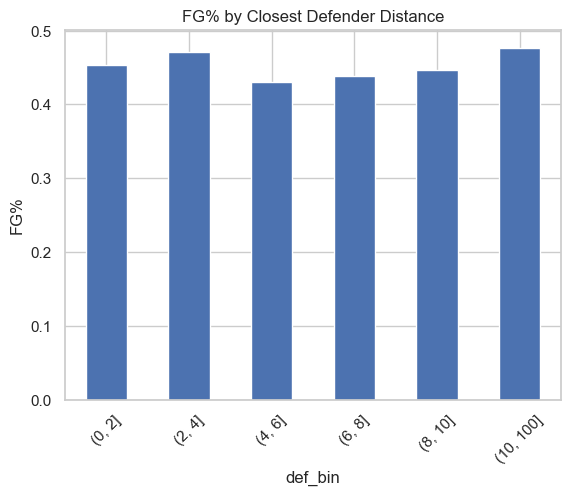

In [12]:
# make rate by defender distance
df["def_bin"] = pd.cut(df["close_def_dist"], bins=[0, 2, 4, 6, 8, 10, 100])
df.groupby("def_bin")["made"].mean().plot(kind="bar", title="FG% by Closest Defender Distance")
plt.ylabel("FG%")
plt.xticks(rotation=45)
plt.show()

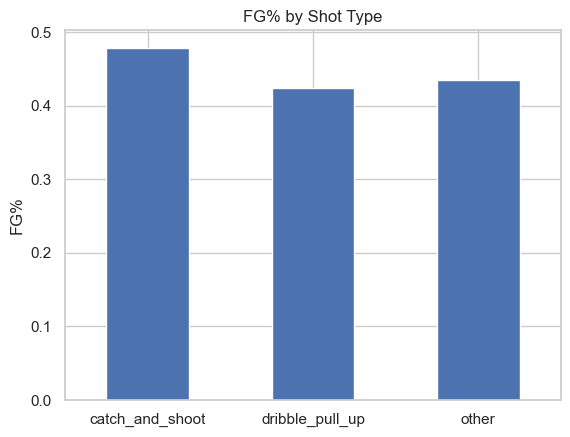

In [13]:
# catch-and-shoot vs dribble pull-up make rates
shot_type = pd.DataFrame({
    "catch_and_shoot": [df[df["catch_and_shoot"]==1]["made"].mean()],
    "dribble_pull_up": [df[df["dribble_pull_up"]==1]["made"].mean()],
    "other": [df[(df["catch_and_shoot"]==0)&(df["dribble_pull_up"]==0)]["made"].mean()],
})
shot_type.T.plot(kind="bar", legend=False, title="FG% by Shot Type")
plt.ylabel("FG%")
plt.xticks(rotation=0)
plt.show()

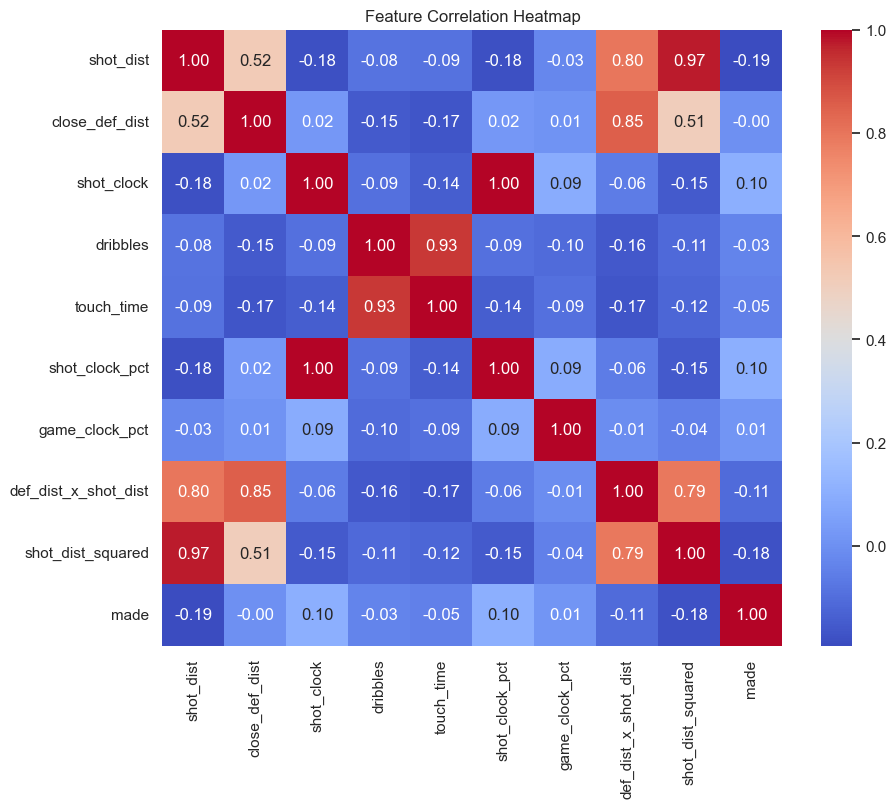

In [14]:
# correlation heatmap of numeric features
num_cols = [
    "shot_dist", "close_def_dist", "shot_clock", "dribbles",
    "touch_time", "shot_clock_pct", "game_clock_pct",
    "def_dist_x_shot_dist", "shot_dist_squared", "made"
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()